# Airbnb Price Prediction - Assessment 1
Student: <your name> (s1234567)
Course: COSC2673 / COSC2793
Date: 11 Apr 2026

## Task definition
Predict nightly price (`price`) of a Melbourne Airbnb listing from provided features in `train_data.csv`. Use the model to generate predictions for `test_data.csv`.

## Evaluation framework
- Hold-out validation: 80/20 train/validation split with `random_state=42`.
- Cross-validation: 5-fold CV on the training split for stability.
- Metrics: MAE, RMSE, R2. Model selection uses validation RMSE, with CV metrics as a secondary check.

## How to run
1. Keep `train_data.csv` and `test_data.csv` in the same folder as this notebook.
2. Run all cells in order from top to bottom.
3. Update `student_number` in the final cell before saving the predictions CSV.
4. The file `{student_number}_predictions.csv` will be created in this folder.

## GenAI usage statement
I used GenAI tools to help with debugging and wording. Prompts used are listed in the report appendix per course policy.

In [29]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')


In [30]:
train_df = pd.read_csv('train_data.csv')
test_df = pd.read_csv('test_data.csv')

## Dataset overview
- Train data contains the target column `price`; test data does not.
- Features include host status, location, room type, capacity, rooms, review metrics, and host listings count.
- Data types and descriptive statistics are shown in the tables below.
- Missing values are checked and summarized in the next section.

In [31]:
print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
display(train_df.head())
display(train_df.dtypes.to_frame('dtype'))


Train shape: (8586, 16)
Test shape: (8585, 15)


,host_is_superhost,city,country,latitude,longitude,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,instant_bookable,calculated_host_listings_count
0,f,Kingston,Australia,-38.022565,145.098937,Entire home/apt,5,1.0,2.0,4.0,111,3,28,94.0,t,1
1,f,Yarra,Australia,-37.782125,144.988079,Entire home/apt,3,1.0,1.0,1.0,80,1,59,93.0,t,1
2,t,Port Phillip,Australia,-37.853710,144.981529,Entire home/apt,4,1.0,1.0,2.0,150,2,14,100.0,f,1
3,f,Glen Eira,Australia,-37.876393,145.036635,Entire home/apt,2,1.0,1.0,1.0,125,1,39,97.0,f,55
4,f,Melbourne,Australia,-37.810398,144.950113,Entire home/apt,3,1.0,1.0,2.0,79,3,7,97.0,t,1


,dtype
host_is_superhost,str
city,str
country,str
latitude,float64
longitude,float64
room_type,str
accommodates,int64
bathrooms,float64
bedrooms,float64
beds,float64


In [32]:
display(train_df.describe(include='all').T)
missing = train_df.isna().sum()
missing = missing[missing > 0]

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
host_is_superhost,8586,2,f,6105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,8586,30,Melbourne,2917,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,8586,1,Australia,8586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,8586.0,NaN,NaN,NaN,-37.825074,0.065145,-38.224427,-37.849202,-37.81646,-37.802849,-37.491059
longitude,8586.0,NaN,NaN,NaN,145.009374,0.130473,144.531993,144.957065,144.977004,145.008316,145.76025
room_type,8586,3,Entire home/apt,5771,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accommodates,8586.0,NaN,NaN,NaN,3.559865,2.225801,1.0,2.0,3.0,4.0,16.0
bathrooms,8586.0,NaN,NaN,NaN,1.28232,0.557906,0.0,1.0,1.0,1.5,9.0
bedrooms,8586.0,NaN,NaN,NaN,1.533077,0.916369,0.0,1.0,1.0,2.0,10.0
beds,8586.0,NaN,NaN,NaN,2.036222,1.544967,0.0,1.0,2.0,2.0,18.0


In [33]:
if missing.empty:
    print("No missing values in train data.")
else:
    display(missing.to_frame("missing"))

No missing values in train data.


In [34]:
# Missingness profile
missing_counts = train_df.isna().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]


In [35]:
if len(missing_counts) > 0:
    plt.figure(figsize=(8, 4))
    sns.barplot(x=missing_counts.index, y=missing_counts.values, color='steelblue')
    plt.xticks(rotation=45, ha='right')
    plt.title('Missing values per feature (train)')
    plt.ylabel('Count of missing values')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values in training data.')

No missing values in training data.


In [36]:
X = train_df.drop(columns=['price'])
y = train_df['price']

categorical_features = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
numeric_features = [c for c in X.columns if c not in categorical_features]

print('Categorical:', categorical_features)
print('Numeric:', numeric_features)

Categorical: ['host_is_superhost', 'city', 'country', 'room_type', 'instant_bookable']
Numeric: ['latitude', 'longitude', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'minimum_nights', 'number_of_reviews', 'review_scores_rating', 'calculated_host_listings_count']


In [37]:
# Quick summary stats for reporting
summary = {
    'train_rows': train_df.shape[0],
    'train_cols': train_df.shape[1],
    'test_rows': test_df.shape[0],
    'test_cols': test_df.shape[1],
    'num_features': X.shape[1],
    'num_numeric': len(numeric_features),
    'num_categorical': len(categorical_features),
    'missing_total': int(train_df.isna().sum().sum()),
    'missing_cols': int((train_df.isna().sum() > 0).sum()),
    'price_min': float(y.min()),
    'price_max': float(y.max()),
    'price_mean': float(y.mean()),
    'price_median': float(y.median()),
    'price_std': float(y.std()),
    'price_skew': float(y.skew())
}
display(pd.DataFrame([summary]))

,train_rows,train_cols,test_rows,test_cols,num_features,num_numeric,num_categorical,missing_total,missing_cols,price_min,price_max,price_mean,price_median,price_std,price_skew
0,8586,16,8585,15,15,10,5,0,0,0.0,3000.0,139.771372,115.0,123.293376,5.765894


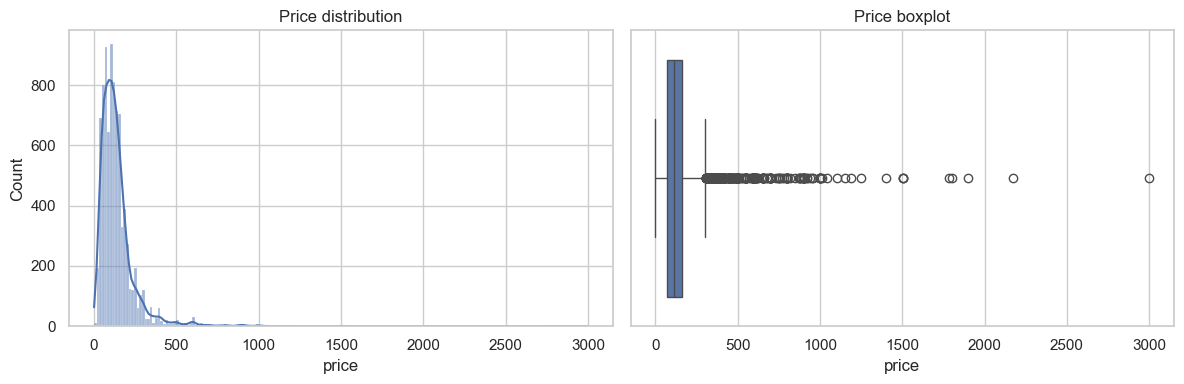

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y, kde=True, ax=axes[0])
axes[0].set_title('Price distribution')
sns.boxplot(x=y, ax=axes[1])
axes[1].set_title('Price boxplot')
plt.tight_layout()
plt.show()


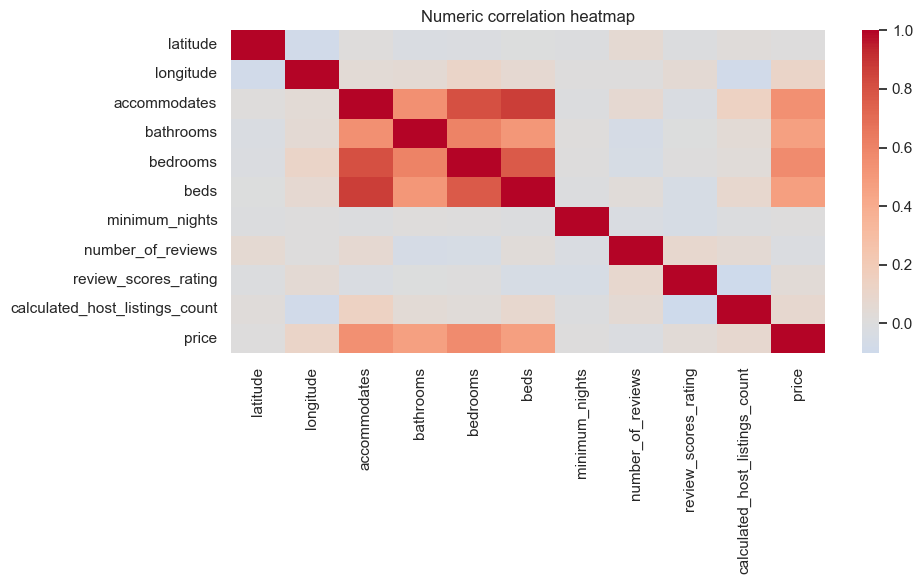

In [39]:
corr = train_df[numeric_features + ['price']].corr(numeric_only=True)
plt.figure(figsize=(10, 6))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Numeric correlation heatmap')
plt.tight_layout()
plt.show()


## Exploratory data analysis (EDA)
The train set has 8,586 rows and 16 columns (15 features + target), and the test set has 8,585 rows and 15 columns. There are 10 numeric and 5 categorical features, and there are no missing values. The target `price` ranges from 0 to 3000 with mean 139.77, median 115.0, std 123.29, and skew 5.77, indicating a strong right skew and high-end outliers (as seen in the histogram and boxplot). The correlation heatmap shows price is most positively associated with capacity and room-related features (accommodates, bedrooms, bathrooms, beds), while review and minimum-night variables are weakly correlated.

## Preprocessing and split
We separate `price` as the target and build numeric and categorical feature lists. Numeric features are imputed with the median and scaled; categorical features are imputed with the most frequent value and one-hot encoded. This creates a consistent pipeline that can be trained and applied to the test set.

## Models evaluated
We compare Linear Regression, Ridge, and Lasso using the same preprocessing pipeline to keep comparisons fair. Ridge and Lasso are tuned over a log-spaced grid of `alpha` values.

In [40]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), numeric_features),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_features)
    ]
)

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [41]:
def metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

In [42]:
def evaluate(name, model):
    pipe = Pipeline([('preprocess', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)

    val_pred = pipe.predict(X_val)
    val_m = metrics(y_val, val_pred)

    cv = cross_validate(
        pipe, X_train, y_train, cv=kfold,
        scoring=('neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2'),
        n_jobs=-1
    )

    return {
        'Model': name,
        'Val_MAE': val_m['MAE'],
        'Val_RMSE': val_m['RMSE'],
        'Val_R2': val_m['R2'],
        'CV_MAE': -cv['test_neg_mean_absolute_error'].mean(),
        'CV_RMSE': -cv['test_neg_root_mean_squared_error'].mean(),
        'CV_R2': cv['test_r2'].mean()
    }, pipe


In [43]:
# Model 1: Linear Regression
linear_row, linear_pipe = evaluate('LinearRegression', LinearRegression())
display(pd.DataFrame([linear_row]))

,Model,Val_MAE,Val_RMSE,Val_R2,CV_MAE,CV_RMSE,CV_R2
0,LinearRegression,47.816145,103.683616,0.395486,47.851442,90.68427,0.43161


In [44]:
# Model 2: Ridge (tune alpha)
ridge_alphas = np.logspace(-3, 3, 13)
ridge_rows = []

for a in ridge_alphas:
    row, _ = evaluate(f'Ridge(alpha={a:.4g})', Ridge(alpha=float(a), random_state=RANDOM_STATE))
    row['alpha'] = a
    ridge_rows.append(row)

ridge_df = pd.DataFrame(ridge_rows).sort_values('Val_RMSE').reset_index(drop=True)
best_ridge_alpha = float(ridge_df.loc[0, 'alpha'])
display(ridge_df.head())

,Model,Val_MAE,Val_RMSE,Val_R2,CV_MAE,CV_RMSE,CV_R2,alpha
0,Ridge(alpha=31.62),47.168279,103.572006,0.396786,47.288202,90.582778,0.432870,31.622777
1,Ridge(alpha=10),47.429135,103.616289,0.396270,47.576748,90.616649,0.432465,10.000000
2,Ridge(alpha=100),46.939860,103.622347,0.396200,47.007291,90.716613,0.431169,100.000000
3,Ridge(alpha=3.162),47.615579,103.650720,0.395869,47.743404,90.655506,0.431982,3.162278
4,Ridge(alpha=1),47.729169,103.668752,0.395659,47.811098,90.671841,0.431773,1.000000


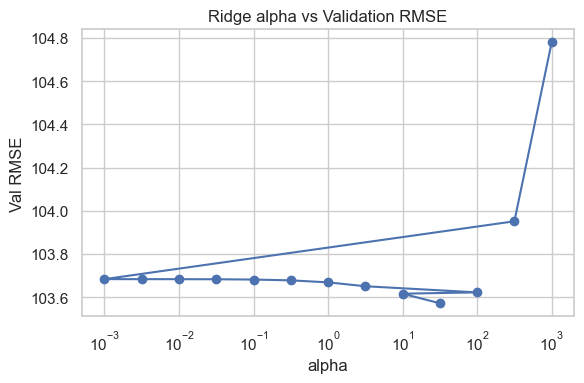

In [45]:
plt.figure(figsize=(6, 4))
plt.plot(ridge_df['alpha'], ridge_df['Val_RMSE'], marker='o')
plt.xscale('log')
plt.title('Ridge alpha vs Validation RMSE')
plt.xlabel('alpha')
plt.ylabel('Val RMSE')
plt.tight_layout()
plt.show()

In [46]:
# Model 3: Lasso (tune alpha)
lasso_alphas = np.logspace(-4, 1, 12)
lasso_rows = []

for a in lasso_alphas:
    row, _ = evaluate(f'Lasso(alpha={a:.4g})', Lasso(alpha=float(a), random_state=RANDOM_STATE, max_iter=20000))
    row['alpha'] = a
    lasso_rows.append(row)

lasso_df = pd.DataFrame(lasso_rows).sort_values('Val_RMSE').reset_index(drop=True)
best_lasso_alpha = float(lasso_df.loc[0, 'alpha'])
display(lasso_df.head())


,Model,Val_MAE,Val_RMSE,Val_R2,CV_MAE,CV_RMSE,CV_R2,alpha
0,Lasso(alpha=0.152),47.006609,103.560857,0.396916,47.244716,90.597853,0.432696,0.151991
1,Lasso(alpha=0.05337),47.334302,103.590273,0.396574,47.546963,90.621019,0.432409,0.053367
2,Lasso(alpha=0.4329),46.626368,103.678475,0.395546,46.855299,90.757726,0.430722,0.432876
3,Lasso(alpha=0.006579),47.722292,103.680698,0.395520,47.810304,90.679079,0.431682,0.006579
4,Lasso(alpha=0.00231),47.780929,103.681465,0.395511,47.836815,90.681440,0.431648,0.002310


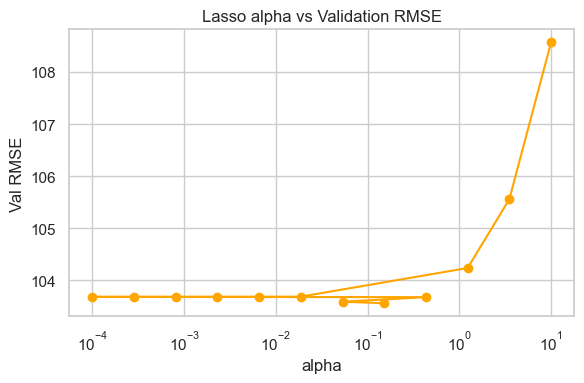

In [47]:
plt.figure(figsize=(6, 4))
plt.plot(lasso_df['alpha'], lasso_df['Val_RMSE'], marker='o', color='orange')
plt.xscale('log')
plt.title('Lasso alpha vs Validation RMSE')
plt.xlabel('alpha')
plt.ylabel('Val RMSE')
plt.tight_layout()
plt.show()


In [48]:
comparison = pd.DataFrame([
    linear_row,
    ridge_df.loc[0].to_dict(),
    lasso_df.loc[0].to_dict()
]).sort_values('Val_RMSE').reset_index(drop=True)

display(comparison[['Model', 'Val_MAE', 'Val_RMSE', 'Val_R2', 'CV_MAE', 'CV_RMSE', 'CV_R2']])
best_model_name = comparison.loc[0, 'Model']
print('Selected model:', best_model_name)

,Model,Val_MAE,Val_RMSE,Val_R2,CV_MAE,CV_RMSE,CV_R2
0,Lasso(alpha=0.152),47.006609,103.560857,0.396916,47.244716,90.597853,0.432696
1,Ridge(alpha=31.62),47.168279,103.572006,0.396786,47.288202,90.582778,0.432870
2,LinearRegression,47.816145,103.683616,0.395486,47.851442,90.684270,0.431610


Selected model: Lasso(alpha=0.152)


## Model evaluation and selection
The table above compares validation MAE/RMSE/R2 and cross-validation metrics for the three models. The selected model is the one with the lowest validation RMSE, with CV results used as a sanity check. If the best model is Ridge or Lasso, the chosen `alpha` is taken from the grid search and is reported in the table output.

In [49]:
if best_model_name.startswith('LinearRegression'):
    selected_estimator = LinearRegression()
elif best_model_name.startswith('Ridge'):
    selected_estimator = Ridge(alpha=best_ridge_alpha, random_state=RANDOM_STATE)
else:
    selected_estimator = Lasso(alpha=best_lasso_alpha, random_state=RANDOM_STATE, max_iter=20000)

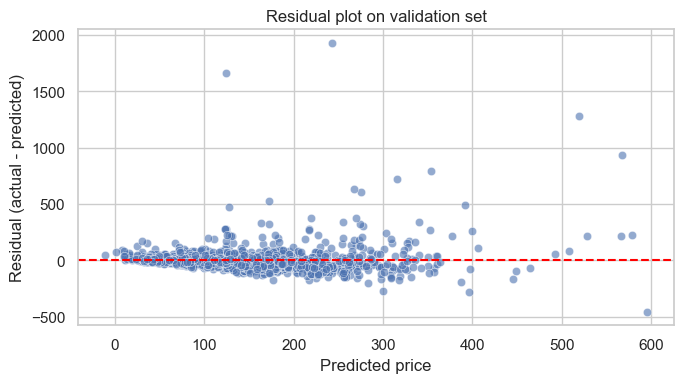

In [50]:
# Error analysis on validation set
analysis_pipe = Pipeline([('preprocess', preprocessor), ('model', selected_estimator)])
analysis_pipe.fit(X_train, y_train)
val_pred = analysis_pipe.predict(X_val)
residuals = y_val - val_pred

plt.figure(figsize=(7, 4))
sns.scatterplot(x=val_pred, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted price')
plt.ylabel('Residual (actual - predicted)')
plt.title('Residual plot on validation set')
plt.tight_layout()
plt.show()

In [51]:
# Feature importance via coefficients (for linear family)
importance_pipe = Pipeline([('preprocess', preprocessor), ('model', selected_estimator)])
importance_pipe.fit(X, y)
model = importance_pipe.named_steps['model']
feature_names = importance_pipe.named_steps['preprocess'].get_feature_names_out()
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': model.coef_})
coef_df = coef_df.sort_values('coefficient')
print('Most negative coefficients:')
display(coef_df.head(10))
print('Most positive coefficients:')
display(coef_df.tail(10))

Most negative coefficients:


,feature,coefficient
39,cat__city_Wyndham,-18.638058
37,cat__city_Whitehorse,-16.670157
45,cat__room_type_Shared room,-10.647926
31,cat__city_Monash,-8.074481
18,cat__city_Darebin,-6.611860
7,num__number_of_reviews,-6.371734
5,num__beds,-3.179536
20,cat__city_Glen Eira,-2.510346
10,cat__host_is_superhost_f,-1.731969
0,num__latitude,-0.501442


Most positive coefficients:


,feature,coefficient
2,num__accommodates,17.349913
13,cat__city_Bayside,22.700860
35,cat__city_Port Phillip,25.418045
3,num__bathrooms,25.667463
40,cat__city_Yarra,26.138856
36,cat__city_Stonnington,27.142381
4,num__bedrooms,33.277055
29,cat__city_Melbourne,33.595685
43,cat__room_type_Entire home/apt,46.857801
41,cat__city_Yarra Ranges,69.044806


## Error analysis and interpretation
Residuals are plotted against predictions to check for bias and heteroscedasticity. Coefficient-based feature importance is reported for the selected linear model to interpret which features increase or decrease price.

## Limitations, ethics, and professional responsibilities
This model assumes linear relationships and may underfit complex patterns. It can inherit biases present in historical data (for example, location or host-related factors). Predictions should be used as decision support rather than an automated pricing decision, and any deployment should include human review and monitoring.

## Improvement ideas
Potential improvements include feature transformations (for skewed variables), richer location features, interaction terms, and more robust validation or ensembling within the allowed methods.

## Final training and submission
The final model is trained on the full training set and used to predict `price` for the test set. The predictions file must be named `{student_number}_predictions.csv` and contain a single column `price` in the same order as `test_data.csv`.

In [52]:
# Train final model on full training data and predict test set
final_pipeline = Pipeline([('preprocess', preprocessor), ('model', selected_estimator)])
final_pipeline.fit(X, y)
test_pred = np.clip(final_pipeline.predict(test_df), a_min=0, a_max=None)

student_number = 's4163448'  # replace with your student number
out_file = f'{student_number}_predictions.csv'
pd.DataFrame({'price': test_pred}).to_csv(out_file, index=False)
print('Saved prediction file:', out_file)
pred_df = pd.DataFrame({'price': test_pred})
display(pred_df.head())
print('Prediction shape:', pred_df.shape)
assert pred_df.shape[0] == test_df.shape[0]
assert list(pred_df.columns) == ['price']

Saved prediction file: s4163448_predictions.csv


,price
0,25.685031
1,128.311573
2,63.767173
3,19.931735
4,83.488276


Prediction shape: (8585, 1)


## References
- Inside Airbnb. https://insideairbnb.com/about/
- Kaggle Melbourne Airbnb open data. https://www.kaggle.com/datasets/tylerx/melbourne-airbnb-open-data
- Scikit-learn documentation. https://scikit-learn.org/